In [82]:
import numpy as np
import matplotlib.pyplot as plt
import afterglowpy as grb
from VegasAfterglow import ISM, TophatJet, Observer, Radiation, Model
import jetsimpy


In [83]:
theta_v = 0
E_iso = 1e53
theta_c = 0.1
n0 = 1
p = 2.5
eps_e = 0.01
eps_B = 0.0001
xi_N = 1
d_L = 1e28
z = 1
Gamma0 = 100

In [84]:
nu_0 = 1e18
t = np.geomspace(1e2, 1.0e6, 300)

In [85]:
# AfterglowPy

# For convenience, place arguments into a dict.
Z = {'jetType':     grb.jet.TopHat,     # Top-Hat jet
     'specType':    grb.jet.DeepNewtonian, # Basic Synchrotron Emission Spectrum

     'thetaObs':    theta_v,   # Viewing angle in radians
     'E0':          E_iso, # Isotropic-equivalent energy in erg
     'thetaCore':   theta_c,    # Half-opening angle in radians
     'n0':          n0,    # circumburst density in cm^{-3}
     'p':           p,    # electron energy distribution index
     'epsilon_e':   eps_e,    # epsilon_e
     'epsilon_B':   eps_B,   # epsilon_B
     'xi_N':        xi_N,    # Fraction of electrons accelerated
     'd_L':         d_L, # Luminosity distance in cm
     'z':           z,
     'spread':      False,
     }

# Calculate flux in a single X-ray band (all times have same frequency)
nu = np.empty(t.shape)
nu[:] = nu_0

# Calculate!

Fnu_agpy = grb.fluxDensity(t, nu, **Z) * 1e-26

In [86]:
# VegasAfterglow

# 1. Define the circumburst environment (constant density ISM)
medium = ISM(n_ism=n0)

# 2. Configure the jet structure (top-hat with opening angle, energy, and Lorentz factor)
jet = TophatJet(theta_c=theta_c, E_iso=E_iso, Gamma0=Gamma0)

# 3. Set observer parameters (distance, redshift, viewing angle)
obs = Observer(lumi_dist=d_L, z=z, theta_obs=theta_v)

# 4. Define radiation microphysics parameters
rad = Radiation(eps_e=eps_e, eps_B=eps_B, p=p, ssc_cooling=True, kn=False)

# 5. Combine all components into a complete afterglow model
model = Model(jet=jet, medium=medium, observer=obs, fwd_rad=rad)

# 3. Calculate the afterglow emission at each time and frequency
results = model.flux_density(t, nu)

In [87]:
# Jetsimpy

P = dict(
    Eiso = E_iso,        # Isotropic equivalent energy
    lf = Gamma0,           # Lorentz factor
    theta_c = theta_c,      # half opening angle
    n0 = n0,             # ism number density
    A = 0,              # wind number density amplitude
    eps_e = eps_e,        # epsilon_e
    eps_b = eps_B,       # epsilon_b
    p = p,           # electron power index
    theta_v = theta_v,      # viewing angle (rad)
    d = d_L,         # distance (Mpc)
    z = z,            # redshift
)

# ---------- (step 1) hydro simulation of the jet ---------- #

# jet without spreading
jet1 = jetsimpy.Jet(
    jetsimpy.Gaussian(P["theta_c"], P["Eiso"], lf0=P["lf"]),    # jet profile
    P["A"],                        # wind number density scale
    P["n0"],                       # ism number density scale
    spread=False,                  # w/wo spreading effect 
    grid=jetsimpy.ForwardJetRes(P["theta_c"], 129)  # resolution
)

# ---------- (step 2) calculate flux density ---------- #

# calculate the afterglow flux density (unit: mJy)
flux1 = jet1.FluxDensity(
    t,           # [second] observing time span
    nu,                # [Hz]     observing frequency
    P,                 # parameter dictionary
)

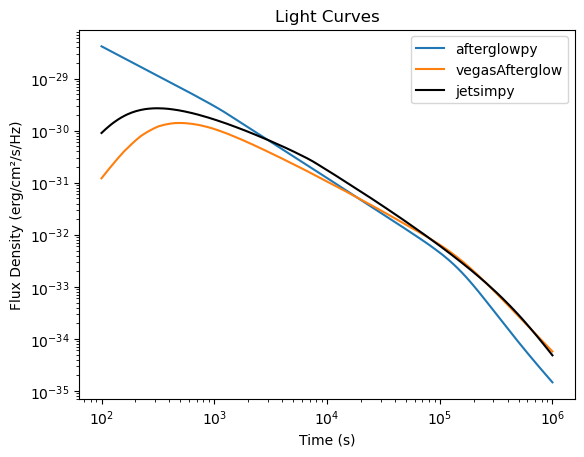

In [88]:
fig, ax = plt.subplots(1, 1)

# AfterglowPy
ax.loglog(t, Fnu_agpy, label='afterglowpy')

########################################################################

# VegasAfterglow
ax.loglog(t, results.total, label=fr'vegasAfterglow',)

########################################################################

# Jetsimpy
ax.plot(t, flux1 / 1e-23, label="jetsimpy", color="black")

ax.set_xlabel('Time (s)')
ax.set_ylabel('Flux Density (erg/cm²/s/Hz)')
ax.legend()
ax.set_title('Light Curves')

plt.show()


<Figure size 960x720 with 0 Axes>

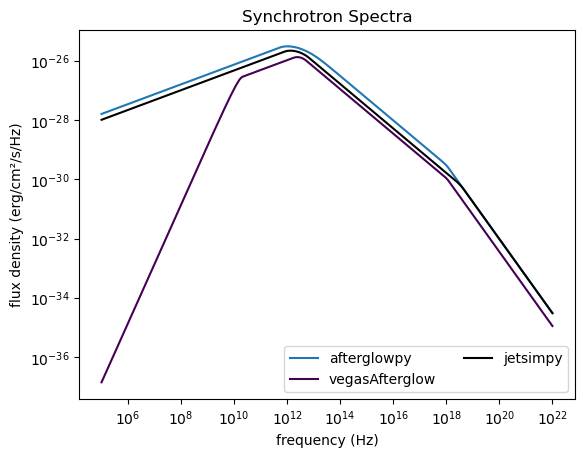

In [89]:
nu = np.logspace(5, 22, 200)  
t0 = 1e3
plt.figure(figsize=(4.8, 3.6),dpi=200)

# Calculate!

Fnu = grb.fluxDensity(t0, nu, **Z) * 1e-26

fig, ax = plt.subplots(1, 1)

plt.loglog(nu, Fnu, label='afterglowpy')


########################################################################
# 2. Select specific time epochs for spectral snapshots 
epochs = np.array([t0])

# 3. Calculate spectra at each epoch
results = model.flux_density_grid(epochs, nu)

# 4. Plot broadband spectra at each epoch
colors = plt.cm.viridis(np.linspace(0,1,len(epochs)))

for i, t in enumerate(epochs):
    exp = int(np.floor(np.log10(t)))
    base = t / 10**exp
    plt.loglog(nu, results.total[:,i], color=colors[i], label=fr'vegasAfterglow')

########################################################################

# calculate the afterglow flux density (unit: mJy)
flux = jet1.FluxDensity(
    t0,           # [second] observing time span
    nu,                # [Hz]     observing frequency
    P,                 # parameter dictionary
)

plt.plot(nu, flux / 1e-23, label="jetsimpy", color="black")

# plt.xlim(1e8, 1e16)
# plt.ylim(1e-28, 1e-24)
plt.xlabel('frequency (Hz)')
plt.ylabel('flux density (erg/cm²/s/Hz)')
plt.legend(ncol=2)
plt.title('Synchrotron Spectra')
plt.savefig('quick-spec.png',dpi=300,bbox_inches='tight')
plt.show()